# Stability vs. training scale, by k (all-features vs. live-only)

Loads SAE checkpoints from the HuggingFace repo, computes cross-seed feature
stability at each (k, token count) pair, and additionally computes stability
restricted to only *live* features (features that fire at least `MIN_FIRINGS`
times on a held-out eval set). Dead features cannot possibly match across
seeds by construction, since their decoder direction is frozen wherever they
stopped receiving gradient -- this notebook checks whether that fully
explains the flat-low stability observed at k=256, or whether a real
residual effect remains.

**Cells in order:**
1. Install dependencies
2. Download checkpoints from the HuggingFace repo
3. Config + SAE class (decoder-similarity matching + true TopK forward pass)
4. Helper functions (stability computation, eval-set construction, firing counts)
5. Main analysis loop
6. Summary table + plot (solid = all features, dashed = live-only)


In [ ]:
!pip install -q transformers datasets huggingface_hub zstandard

In [ ]:
from huggingface_hub import hf_hub_download
import shutil, os

CHECKPOINT_DIR = "checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

REPO_ID = "deenais/sae-stability-pythia70m"
HUB_PREFIX = "checkpoints/topk64-128-256_x16_tied_auxk"

SEEDS = [42, 256, 1024]
KS = [64, 128, 256]
# Full six-checkpoint grid, matching the original stability-vs-tokens plot.
TOKEN_COUNTS = [50_000_000, 100_000_000, 250_000_000, 500_000_000, 800_000_000, 1_000_000_000]

n_downloaded, n_failed = 0, 0
for tokens in TOKEN_COUNTS:
    for k in KS:
        for seed in SEEDS:
            fname = f"seed{seed}_k{k}_tokens{tokens}.pt"
            try:
                local_path = hf_hub_download(repo_id=REPO_ID, filename=f"{HUB_PREFIX}/{fname}")
                shutil.copy(local_path, f"{CHECKPOINT_DIR}/{fname}")
                n_downloaded += 1
            except Exception as e:
                print(f"Missing or failed: {fname} ({e})")
                n_failed += 1

print(f"\nDownloaded {n_downloaded} checkpoints, {n_failed} missing/failed.")

checkpoints/topk64-128-256_x16_tied_auxk(…): reconstructing file:   0%|          |  0.00B /  101MB            

checkpoints/topk64-128-256_x16_tied_auxk(…): downloading bytes:           |  0.00B            

checkpoints/topk64-128-256_x16_tied_auxk(…): reconstructing file:   0%|          |  0.00B /  101MB            

checkpoints/topk64-128-256_x16_tied_auxk(…): downloading bytes:           |  0.00B            

checkpoints/topk64-128-256_x16_tied_auxk(…): reconstructing file:   0%|          |  0.00B /  101MB            

...

checkpoints/topk64-128-256_x16_tied_auxk(…): reconstructing file:   0%|          |  0.00B /  101MB            

checkpoints/topk64-128-256_x16_tied_auxk(…): downloading bytes:           |  0.00B            

checkpoints/topk64-128-256_x16_tied_auxk(…): reconstructing file:   0%|          |  0.00B /  101MB            

checkpoints/topk64-128-256_x16_tied_auxk(…): downloading bytes:           |  0.00B            


Downloaded 54 checkpoints, 0 missing/failed.


In [ ]:
import re
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from typing import Dict, List, Tuple
from transformers import AutoModel, AutoTokenizer
from datasets import load_dataset

MIN_SEEDS = 2   # analyze a (k, token_count) pair if >= this many seeds exist
THETA = 0.7     # Gerasimov et al. decoder-only matching threshold
EPSILON = 0.05  # endpoint binarization

# Firing floor for the live-only computation. Matches the floor already
# established elsewhere in the pipeline (>=100 firings across the held-out
# eval set), not the looser >=1 threshold used in an earlier quick check.
MIN_FIRINGS = 100
N_EVAL_BATCHES = 40  # matches sae_stats.py's held-out eval set size


class SparseAutoencoder(nn.Module):
    """Reconstructs both the decoder-only similarity computation (unchanged
    from the original script) and, when k is known, the true TopK forward
    pass needed for firing counts."""

    def __init__(self, d_model: int, n_features: int, k: int = None, seed: int = None):
        super().__init__()
        if seed is not None:
            torch.manual_seed(seed)
        self.d_model = d_model
        self.n_features = n_features
        self.k = k
        self.W_enc = nn.Parameter(torch.randn(d_model, n_features) * 0.01)
        self.b_enc = nn.Parameter(torch.zeros(n_features))
        self.W_dec = nn.Parameter(torch.randn(n_features, d_model) * 0.01)
        self.b_dec = nn.Parameter(torch.zeros(d_model))
        with torch.no_grad():
            self.W_dec.data = F.normalize(self.W_dec.data, dim=1)

    def encode_topk(self, x: torch.Tensor) -> torch.Tensor:
        """True TopK forward pass (matches the training architecture): TopK
        applied directly to the pre-activation, no ReLU. Used for firing
        counts, not for the decoder-similarity stability computation."""
        assert self.k is not None, "k must be set to run the TopK forward pass"
        pre_acts = (x - self.b_dec) @ self.W_enc + self.b_enc
        topk_vals, topk_idx = pre_acts.topk(self.k, dim=-1)
        f = torch.zeros_like(pre_acts)
        f.scatter_(-1, topk_idx, topk_vals)
        return f

In [ ]:
def compute_decoder_similarity(sae1, sae2) -> torch.Tensor:
    W1 = F.normalize(sae1.W_dec.detach(), dim=1)
    W2 = F.normalize(sae2.W_dec.detach(), dim=1)
    return (W1 @ W2.T).cpu()


def compute_reappearance_probability(saes: Dict[int, SparseAutoencoder], theta: float) -> np.ndarray:
    """Decoder-only, many-to-one argmax matching (Gerasimov et al. Eq. 3-4)."""
    seeds = list(saes.keys())
    anchor_sae = saes[seeds[0]]
    n_features = anchor_sae.n_features
    reappearance_counts = np.zeros(n_features)

    for other_seed in seeds[1:]:
        sim_matrix = compute_decoder_similarity(anchor_sae, saes[other_seed])
        best_sim, _ = sim_matrix.max(dim=1)
        reappearance_counts += (best_sim.numpy() >= theta).astype(float)

    return reappearance_counts / (len(seeds) - 1)


def find_groups_with_seeds(
    checkpoint_dir: str, seeds: list, ks: list, min_seeds: int = 2
) -> Dict[Tuple[int, int], List[int]]:
    """Return {(k, token_count): [seeds present]} for groups with >= min_seeds checkpoints."""
    ckpt_dir = Path(checkpoint_dir)
    pattern = re.compile(r"seed(\d+)_k(\d+)_tokens(\d+)\.pt")
    seed_set = set(seeds)
    k_set = set(ks)
    seeds_by_group: Dict[Tuple[int, int], set] = {}

    for f in ckpt_dir.glob("seed*_k*_tokens*.pt"):
        m = pattern.match(f.name)
        if not m:
            continue
        seed, k, tokens = int(m.group(1)), int(m.group(2)), int(m.group(3))
        if seed not in seed_set or k not in k_set:
            continue
        seeds_by_group.setdefault((k, tokens), set()).add(seed)

    return {
        g: sorted(s)
        for g, s in sorted(seeds_by_group.items())
        if len(s) >= min_seeds
    }


def load_saes_at_group(checkpoint_dir: str, seeds: list, k: int, token_count: int) -> Dict[int, SparseAutoencoder]:
    saes = {}
    for seed in seeds:
        path = Path(checkpoint_dir) / f"seed{seed}_k{k}_tokens{token_count}.pt"
        ckpt = torch.load(path, map_location="cpu", weights_only=False)
        cfg = ckpt["config"]
        ckpt_k = ckpt.get("k", cfg.get("k", k))
        sae = SparseAutoencoder(cfg["d_model"], cfg["n_features"], k=ckpt_k, seed=seed)
        sae.load_state_dict(ckpt["model_state_dict"])
        saes[seed] = sae
    return saes


def load_hf_model(model_name: str, device: str):
    """Plain transformers loader (no transformer_lens): AutoModel (base
    transformer, no lm_head) avoids computing the ~50k-vocab logits tensor."""
    hf_name = model_name if "/" in model_name else f"EleutherAI/{model_name}"
    tokenizer = AutoTokenizer.from_pretrained(hf_name)
    try:
        model = AutoModel.from_pretrained(hf_name, dtype=torch.float32)
    except TypeError:
        model = AutoModel.from_pretrained(hf_name, torch_dtype=torch.float32)
    model.to(device)
    model.eval()
    return model, tokenizer


def build_eval_activations(model, tokenizer, hook_point: str, seq_len: int, batch_size: int,
                            device: str, n_batches: int) -> torch.Tensor:
    """hook_point looks like 'blocks.3.hook_resid_post'. In plain HF's
    output_hidden_states, hidden_states[i] is the residual stream after
    layer i (i=1..n_layers), so layer L corresponds to hidden_states[L+1]."""
    layer_idx = int(hook_point.split(".")[1])
    hs_index = layer_idx + 1

    dataset = load_dataset("monology/pile-uncopyrighted", split="train", streaming=True)
    token_buffer = []
    batches = []

    for example in dataset:
        tokens = tokenizer(
            example["text"], return_tensors="pt", truncation=True, max_length=seq_len * 10
        )["input_ids"][0]
        token_buffer.extend(tokens.tolist())

        while len(token_buffer) >= seq_len * batch_size:
            batch_tokens = torch.tensor(
                token_buffer[: seq_len * batch_size]
            ).reshape(batch_size, seq_len)
            token_buffer = token_buffer[seq_len * batch_size:]

            with torch.no_grad():
                out = model(batch_tokens.to(device), output_hidden_states=True)
                acts = out.hidden_states[hs_index]
                acts = acts.reshape(-1, acts.shape[-1]).cpu()
            batches.append(acts)

            if len(batches) >= n_batches:
                return torch.cat(batches, dim=0)

    return torch.cat(batches, dim=0)


def compute_firing_counts(sae: SparseAutoencoder, activations: torch.Tensor,
                           device: str, batch_size: int = 4096) -> np.ndarray:
    """Count, per feature, how many held-out tokens it enters the top-k set on."""
    sae = sae.to(device)
    sae.eval()
    counts = torch.zeros(sae.n_features, device=device)

    with torch.no_grad():
        for start in range(0, len(activations), batch_size):
            batch = activations[start:start + batch_size].to(device)
            f = sae.encode_topk(batch)
            counts += (f != 0).sum(dim=0).float()

    return counts.cpu().numpy()

In [ ]:
available = find_groups_with_seeds(CHECKPOINT_DIR, SEEDS, KS, min_seeds=MIN_SEEDS)

if not available:
    raise SystemExit(
        f"No (k, token_count) group has >= {MIN_SEEDS} seeds among {SEEDS} x k={KS}. "
        f"Check that the download cell above completed successfully."
    )

print("Analyzing (k, token_count) groups (seeds used per group):")
for (k, t), seeds_here in available.items():
    print(f"  k={k}, tokens={t:,}: {seeds_here}")
print()

# --- build the held-out eval set once, reused for every checkpoint ---------------
sample_ckpt_path = None
for (k, t), seeds_here in available.items():
    p = Path(CHECKPOINT_DIR) / f"seed{seeds_here[0]}_k{k}_tokens{t}.pt"
    if p.exists():
        sample_ckpt_path = p
        break

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

activations = None
if sample_ckpt_path is not None:
    sample_ckpt = torch.load(sample_ckpt_path, map_location="cpu", weights_only=False)
    cfg = sample_ckpt["config"]
    model_name = cfg.get("model_name", "pythia-70m-deduped")
    hook_point = cfg["hook_point"]
    seq_len = cfg.get("seq_len", 128)
    batch_size = cfg.get("batch_size", 256)

    print(f"Building held-out eval set for live-feature computation "
          f"({model_name}, {hook_point}, {N_EVAL_BATCHES} batches)...")
    model, tokenizer = load_hf_model(model_name, device)
    activations = build_eval_activations(
        model, tokenizer, hook_point, seq_len, batch_size, device, N_EVAL_BATCHES
    )
    print(f"Eval activations: {activations.shape}\n")
else:
    print("WARNING: could not find a checkpoint to read config from; "
          "skipping live-only computation, all-features results only.\n")

results = []
for (k, token_count), seeds_here in available.items():
    saes = load_saes_at_group(CHECKPOINT_DIR, seeds_here, k, token_count)
    p_hat = compute_reappearance_probability(saes, theta=THETA)

    stable_mask = (p_hat >= (1 - EPSILON))
    unstable = (p_hat <= EPSILON).sum()
    discarded = len(p_hat) - stable_mask.sum() - unstable

    pct_stable_live = float("nan")
    pct_live = float("nan")
    if activations is not None:
        anchor_seed = seeds_here[0]
        anchor_sae = saes[anchor_seed]
        firing_counts = compute_firing_counts(anchor_sae, activations, device)
        live_mask = firing_counts >= MIN_FIRINGS
        pct_live = 100 * live_mask.mean()
        if live_mask.sum() > 0:
            pct_stable_live = 100 * stable_mask[live_mask].mean()

    results.append({
        "k": k,
        "token_count": token_count,
        "seeds": seeds_here,
        "n_seeds": len(seeds_here),
        "n_features": len(p_hat),
        "mean_p_hat": p_hat.mean(),
        "stable": int(stable_mask.sum()),
        "unstable": int(unstable),
        "discarded": int(discarded),
        "pct_stable": 100 * stable_mask.mean(),
        "pct_stable_live": pct_stable_live,
        "pct_live": pct_live,
    })

    print(f"--- k={k}, {token_count:,} tokens (seeds={seeds_here}) ---")
    print(f"  Mean p_hat:  {p_hat.mean():.4f}")
    print(f"  Stable (all):  {int(stable_mask.sum())} ({100 * stable_mask.mean():.1f}%)")
    if not np.isnan(pct_stable_live):
        print(f"  Stable (live): {100 * stable_mask.mean():.1f}% -> {pct_stable_live:.1f}% "
              f"among the {pct_live:.1f}% of features that fired >= {MIN_FIRINGS} times")
    print(f"  Unstable:    {int(unstable)} ({100 * unstable / len(p_hat):.1f}%)")
    print(f"  Discarded:   {int(discarded)} ({100 * discarded / len(p_hat):.1f}%)")
    print()

Analyzing (k, token_count) groups (seeds used per group):
  k=64, tokens=50,000,000: [42, 256, 1024]
  k=64, tokens=100,000,000: [42, 256, 1024]
  k=64, tokens=250,000,000: [42, 256, 1024]
  k=64, tokens=500,000,000: [42, 256, 1024]
  k=64, tokens=800,000,000: [42, 256, 1024]
  k=64, tokens=1,000,000,000: [42, 256, 1024]
  k=128, tokens=50,000,000: [42, 256, 1024]
  k=128, tokens=100,000,000: [42, 256, 1024]
  k=128, tokens=250,000,000: [42, 256, 1024]
  k=128, tokens=500,000,000: [42, 256, 1024]
  k=128, tokens=800,000,000: [42, 256, 1024]
  k=128, tokens=1,000,000,000: [42, 256, 1024]
  k=256, tokens=50,000,000: [42, 256, 1024]
  k=256, tokens=100,000,000: [42, 256, 1024]
  k=256, tokens=250,000,000: [42, 256, 1024]
  k=256, tokens=500,000,000: [42, 256, 1024]
  k=256, tokens=800,000,000: [42, 256, 1024]
  k=256, tokens=1,000,000,000: [42, 256, 1024]

Using device: cuda
Building held-out eval set for live-feature computation (pythia-70m-deduped, blocks.3.hook_resid_post, 40 batches).

config.json:   0%|          | 0.00/567 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/75 [00:00<?, ?it/s]

[transformers] GPTNeoXModel LOAD REPORT from: EleutherAI/pythia-70m-deduped
Key              | Status     |  | 
-----------------+------------+--+-
embed_out.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


README.md:   0%|          | 0.00/776 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

Eval activations: torch.Size([1310720, 512])

--- k=64, 50,000,000 tokens (seeds=[42, 256, 1024]) ---
  Mean p_hat:  0.1702
  Stable (all):  983 (12.0%)
  Stable (live): 12.0% -> 13.7% among the 87.9% of features that fired >= 100 times
  Unstable:    6387 (78.0%)
  Discarded:   822 (10.0%)

--- k=64, 100,000,000 tokens (seeds=[42, 256, 1024]) ---
  Mean p_hat:  0.3163
  Stable (all):  1974 (24.1%)
  Stable (live): 24.1% -> 27.2% among the 88.1% of features that fired >= 100 times
  Unstable:    4983 (60.8%)
  Discarded:   1235 (15.1%)

--- k=64, 250,000,000 tokens (seeds=[42, 256, 1024]) ---
  Mean p_hat:  0.5547
  Stable (all):  3761 (45.9%)
  Stable (live): 45.9% -> 47.7% among the 93.8% of features that fired >= 100 times
  Unstable:    2865 (35.0%)
  Discarded:   1566 (19.1%)

--- k=64, 500,000,000 tokens (seeds=[42, 256, 1024]) ---
  Mean p_hat:  0.6649
  Stable (all):  4742 (57.9%)
  Stable (live): 57.9% -> 58.6% among the 96.1% of features that fired >= 100 times
  Unstable:   

In [ ]:
print("=" * 96)
print("SUMMARY: stability vs. training token count, by k (all-features vs. live-only)")
print("=" * 96)
print(f"{'k':>6} {'Tokens':>15} {'n_seeds':>8} {'Mean p_hat':>12} "
      f"{'% Stable(all)':>14} {'% Stable(live)':>15} {'% live':>8}")
for r in results:
    live_str = f"{r['pct_stable_live']:.1f}%" if not np.isnan(r["pct_stable_live"]) else "n/a"
    pct_live_str = f"{r['pct_live']:.1f}%" if not np.isnan(r["pct_live"]) else "n/a"
    print(
        f"{r['k']:>6} {r['token_count']:>15,} {r['n_seeds']:>8} {r['mean_p_hat']:>12.4f} "
        f"{r['pct_stable']:>13.1f}% {live_str:>15} {pct_live_str:>8}"
    )

import os
os.makedirs("outputs", exist_ok=True)
np.savez(
    "outputs/stability_by_token_count.npz",
    k=np.array([r["k"] for r in results]),
    token_counts=np.array([r["token_count"] for r in results]),
    n_seeds=np.array([r["n_seeds"] for r in results]),
    mean_p_hat=np.array([r["mean_p_hat"] for r in results]),
    pct_stable=np.array([r["pct_stable"] for r in results]),
    pct_stable_live=np.array([r["pct_stable_live"] for r in results]),
    pct_live=np.array([r["pct_live"] for r in results]),
)
print("\nSaved summary to outputs/stability_by_token_count.npz")

SUMMARY: stability vs. training token count, by k (all-features vs. live-only)
     k          Tokens  n_seeds   Mean p_hat  % Stable(all)  % Stable(live)   % live
    64      50,000,000        3       0.1702          12.0%           13.7%    87.9%
    64     100,000,000        3       0.3163          24.1%           27.2%    88.1%
    64     250,000,000        3       0.5547          45.9%           47.7%    93.8%
    64     500,000,000        3       0.6649          57.9%           58.6%    96.1%
    64     800,000,000        3       0.7034          62.4%           62.8%    97.3%
    64   1,000,000,000        3       0.7197          64.2%           64.5%    97.3%
   128      50,000,000        3       0.0697           4.4%            6.2%    70.6%
   128     100,000,000        3       0.1661          11.3%           16.5%    68.2%
   128     250,000,000        3       0.3928          30.6%           37.7%    76.3%
   128     500,000,000        3       0.5686          47.4%           5

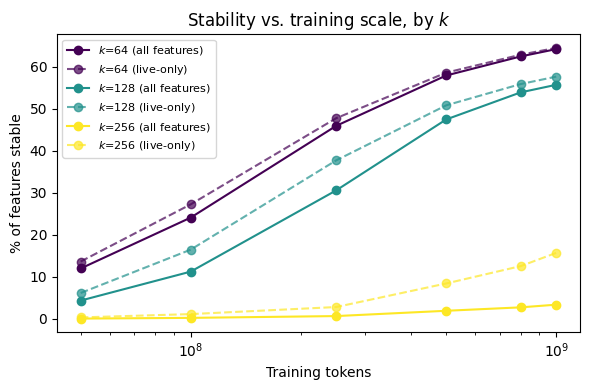

Saved plot to outputs/stability_by_token_count.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

ks_present = sorted(set(r["k"] for r in results))

# Map k to a position in [0, 1] along viridis, using log-scale since k doubles each step
log_ks = np.log2(ks_present)
norm = mcolors.Normalize(vmin=log_ks.min(), vmax=log_ks.max())
cmap = plt.cm.viridis

fig, ax = plt.subplots(1, 1, figsize=(6, 4))

for k in ks_present:
    color = cmap(norm(np.log2(k)))
    rows = [r for r in results if r["k"] == k]
    rows.sort(key=lambda r: r["token_count"])
    token_counts = [r["token_count"] for r in rows]
    pct_stable = [r["pct_stable"] for r in rows]
    pct_stable_live = [r["pct_stable_live"] for r in rows]

    ax.plot(token_counts, pct_stable, marker="o", color=color, label=f"$k$={k} (all features)")
    if not all(np.isnan(pct_stable_live)):
        ax.plot(token_counts, pct_stable_live, marker="o", linestyle="--",
                 color=color, alpha=0.7, label=f"$k$={k} (live-only)")

ax.set_xscale("log")
ax.set_xlabel("Training tokens")
ax.set_ylabel("% of features stable")
ax.set_title("Stability vs. training scale, by $k$")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("outputs/stability_by_token_count.png", dpi=150)
plt.show()
print("Saved plot to outputs/stability_by_token_count.png")